In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
df=pd.read_table("/content/bank.csv",sep=",")

In [5]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  int64
 2   marital    11162 non-null  int64
 3   education  11162 non-null  int64
 4   default    11162 non-null  int64
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  int64
 7   loan       11162 non-null  int64
 8   contact    11162 non-null  int64
 9   day        11162 non-null  int64
 10  month      11162 non-null  int64
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  int64
 16  deposit    11162 non-null  int64
dtypes: int64(17)
memory usage: 1.4 MB


In [7]:
df.describe()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,4.487905,1.199337,1.285164,0.015051,1528.538524,0.473123,0.130801,0.489697,15.658036,5.445709,371.993818,2.508421,51.330407,0.832557,2.477782,0.473840
std,11.913369,3.225132,0.625552,0.749478,0.121761,3225.413326,0.499299,0.337198,0.818724,8.420740,3.191939,347.128386,2.722077,108.758282,2.292007,1.002952,0.499338
min,18.000000,0.000000,0.000000,0.000000,0.000000,-6847.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,-1.000000,0.000000,0.000000,0.000000
25%,32.000000,1.000000,1.000000,1.000000,0.000000,122.000000,0.000000,0.000000,0.000000,8.000000,3.000000,138.000000,1.000000,-1.000000,0.000000,2.000000,0.000000
50%,39.000000,4.000000,1.000000,1.000000,0.000000,550.000000,0.000000,0.000000,0.000000,15.000000,6.000000,255.000000,2.000000,-1.000000,0.000000,3.000000,0.000000
75%,49.000000,7.000000,2.000000,2.000000,0.000000,1708.000000,1.000000,0.000000,1.000000,22.000000,8.000000,496.000000,3.000000,20.750000,1.000000,3.000000,1.000000
max,95.000000,11.000000,2.000000,3.000000,1.000000,81204.000000,1.000000,1.000000,2.000000,31.000000,11.000000,3881.000000,63.000000,854.000000,58.000000,3.000000,1.000000


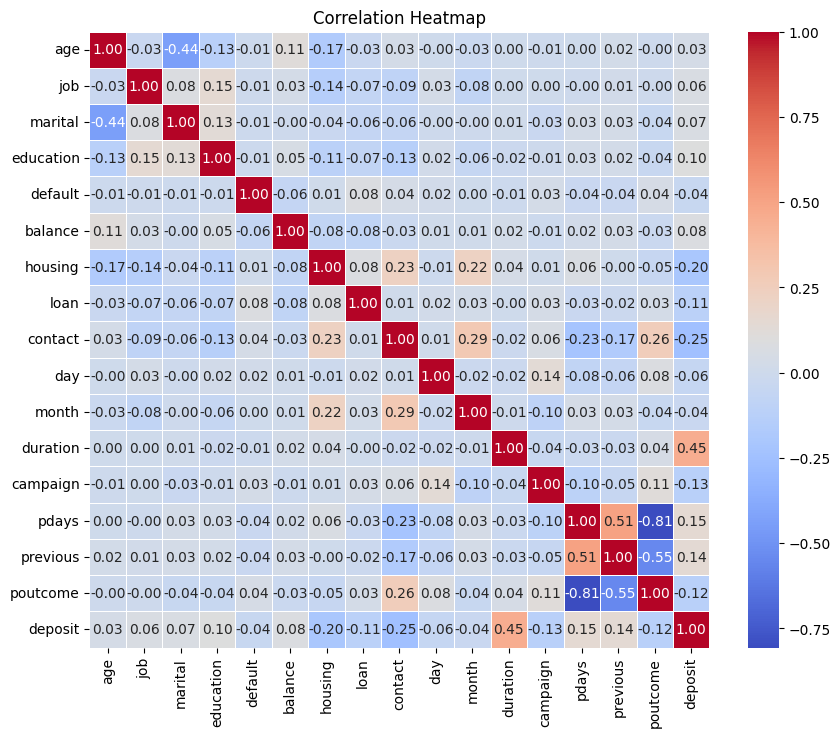

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

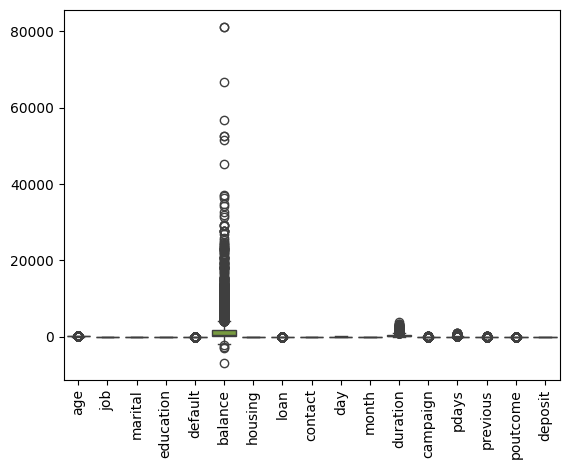

In [9]:
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=90)
plt.show()

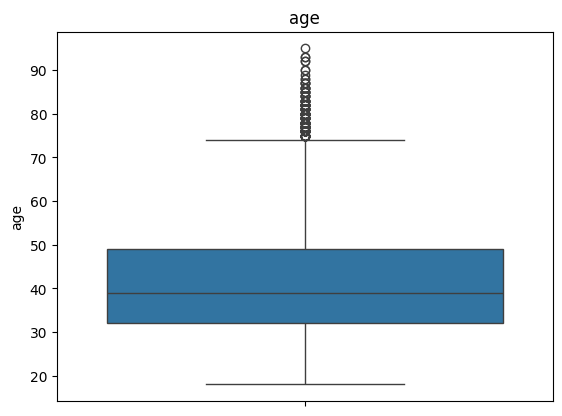

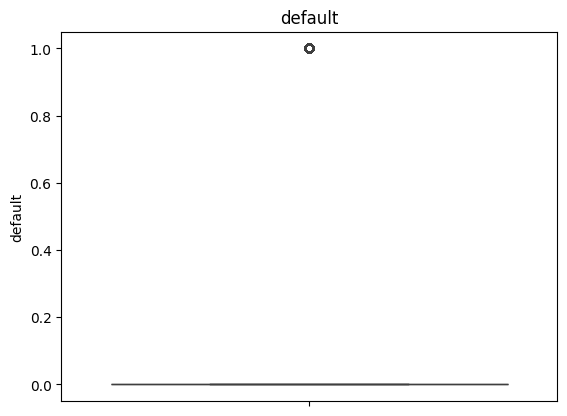

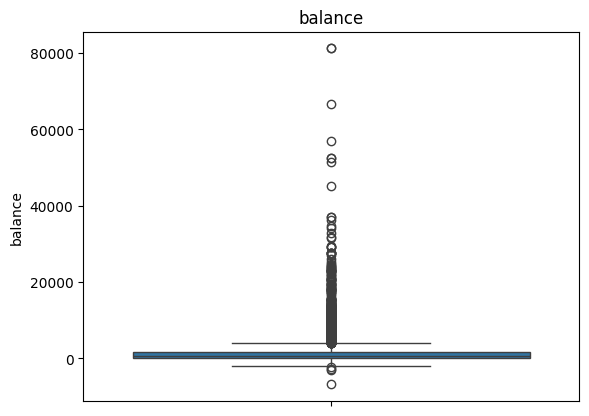

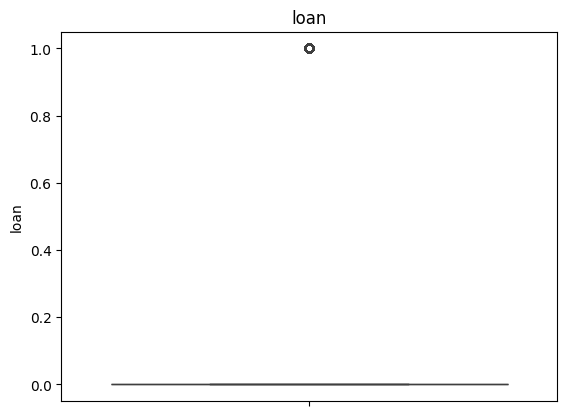

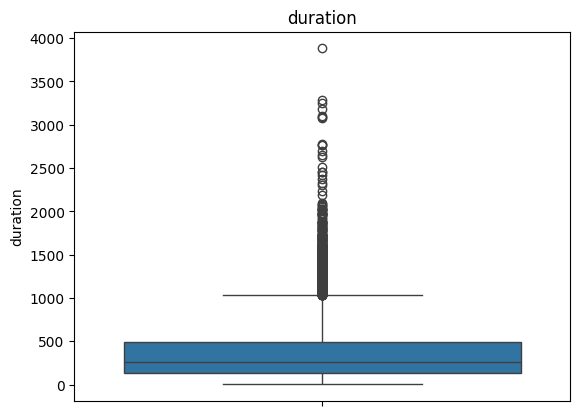

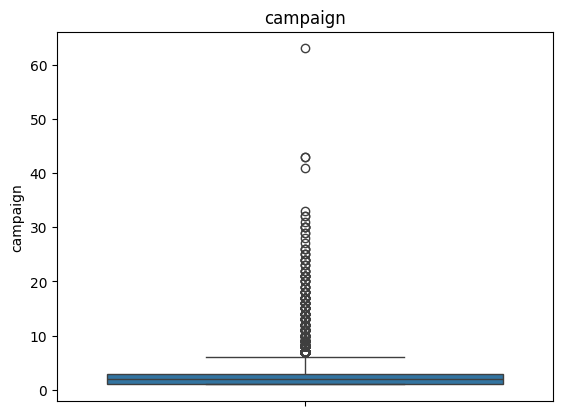

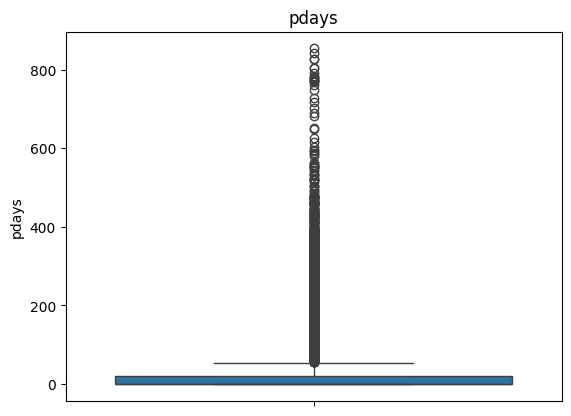

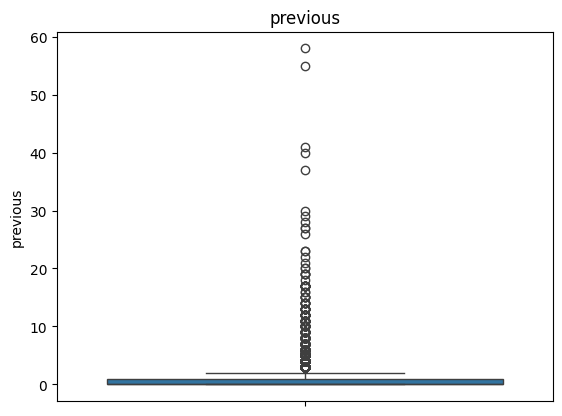

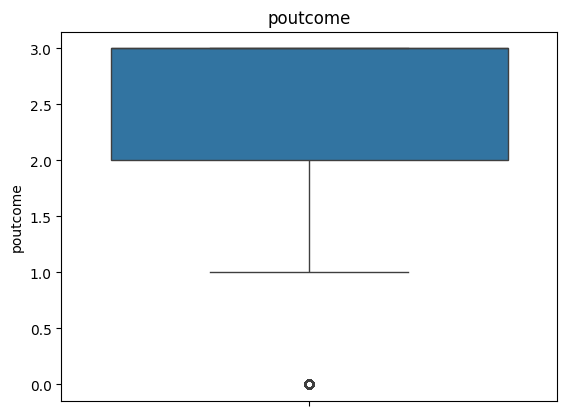

In [10]:
colname=['age','default','balance','loan','duration','campaign','pdays','previous','poutcome']
for col in colname:
    sns.boxplot(df[col])
    plt.title(f"{col}")
    plt.show()

In [11]:
from sklearn.tree import DecisionTreeClassifier

In [12]:
data={
    "Study_hours":[1,2,3,4,5,6,7,8,2,6],
    "Mobile_Usage":[5,4,6,3,2,2,1,1,5,2],
    "Sleep_hours":[8,7,6,6,7,7,6,5,8,6],
    "Result":[0,0,0,1,1,1,1,1,0,1]
}
df=pd.DataFrame(data)
df

,Study_hours,Mobile_Usage,Sleep_hours,Result
0,1,5,8,0
1,2,4,7,0
2,3,6,6,0
3,4,3,6,1
4,5,2,7,1
5,6,2,7,1
6,7,1,6,1
7,8,1,5,1
8,2,5,8,0
9,6,2,6,1


In [13]:
X = df.iloc[:,:-1]
Y = df.iloc[:,-1]

Initialize weights

In [14]:
weiths= np.ones(len(Y))/len(Y)
print(f"Initial weights: {weiths}")

Initial weights: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]


In [15]:
models=[]
alphas=[]

for i in range(5):
  model= DecisionTreeClassifier(max_depth=1)
  model.fit(X,Y,sample_weight=weiths)
  pred=model.predict(X)

  #calculatew error
  error=np.sum(weiths*(pred != Y))

  #avoid divide by zero
  error = max(error, 1e-10)

  #calculate model weight (alpha)
  alpha = 0.5 * np.log((1 - error) / error)

  #update weights
  weiths = weiths * np.exp(-alpha * Y * pred)

  #normalize weights
  weiths = weiths / np.sum(weiths)

#Final prdiction Function
def predicted_boosting(X_input):
  final_pred = np.zeros(len(X_input))
  for alpha, model in zip(alphas, models):
    pred = model.predict(X_input)
    final_pred += alpha * pred
  return np.sign(final_pred)


In [16]:
ns=np.array([[5,3,3 ]])
result = predicted_boosting(ns)
if result[0] == 1:
    print("The student will pass the exam.")
else:
    print("The student will fail the exam.")

The student will fail the exam.


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [17]:
data = {
    'Study_hours': [1, 2, 3, 4, 5, 6, 7, 8, 2, 6],
    'Attendance': [40,50,55,60,65,70,75,80,45,72],
    'Result': ["Fail", "Fail", "Fail", "Pass", "Pass", "Pass", "Pass", "Pass", "Fail", "Pass"]
}

In [20]:
df=pd.DataFrame(data)
df

,Study_hours,Attendance,Result
0,1,40,Fail
1,2,50,Fail
2,3,55,Fail
3,4,60,Pass
4,5,65,Pass
5,6,70,Pass
6,7,75,Pass
7,8,80,Pass
8,2,45,Fail
9,6,72,Pass


In [21]:
df['Result'] = df['Result'].map({'Fail': 0, 'Pass': 1})

In [22]:
df

,Study_hours,Attendance,Result
0,1,40,0
1,2,50,0
2,3,55,0
3,4,60,1
4,5,65,1
5,6,70,1
6,7,75,1
7,8,80,1
8,2,45,0
9,6,72,1


In [23]:
X=df.drop(columns=['Result'])
Y=df['Result']

In [26]:
X

,Study_hours,Attendance
0,1,40
1,2,50
2,3,55
3,4,60
4,5,65
5,6,70
6,7,75
7,8,80
8,2,45
9,6,72


In [35]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=1)

weak learner

In [36]:
base_model=DecisionTreeClassifier(max_depth=1)

ADA booster

In [37]:
model=AdaBoostClassifier(n_estimators=10,)

traning the model

In [38]:
model.fit(X_train,Y_train)

AdaBoostClassifier(n_estimators=10)

we required ypred

In [41]:
ypred=model.predict(X_test)
print(f"Ypred: {ypred} accuracy: {accuracy_score(Y_test,ypred)}")

Ypred: [0 1] accuracy: 1.0


for the new obser

In [46]:
def mymodel(a,b):
  newobs=[[a,b]]
  prediction = model.predict(newobs)
  if prediction[0] == 1:
    print("The student will pass the exam.")
  else:
      print("The student will fail the exam.")

In [47]:
mymodel(4, 70)

The student will pass the exam.
